# Task 3 — Neuro-Symbolic Filtering & Ranking (New Dataset)

## Context

| Layer | Role | Who |
|-------|------|-----|
| Layer 1 | Ontology → Knowledge Graph (`nodes.csv` / `edges.csv`) | Davide |
| Layer 2 | Neural link predictions (`best_model_all_predictions.csv`) | Aya |
| **Layer 3** | **Symbolic filter: reject predictions that violate the ontology** | **This notebook** |
| **Layer 4** | **Combine neural score + ontological confidence → final ranking** | **This notebook** |
| Layer 5 | Explanation generation | Task 4 |

## What this notebook does

The neural model (Task 2) predicts a probability for every possible pair
`(Java topic → game element)`. The problem is that it gives the **same probability**
to all game elements for the same topic — it cannot distinguish between them.

That is exactly why **Layer 3 and Layer 4 are critical**: the ontology graph
contains structural information that the neural model missed, and we use it
to filter bad predictions and produce a meaningful ranking.

## Files required (upload to Colab before running)
- `best_model_all_predictions.csv` — output of Task 2
- `nodes.csv` — ontology nodes (Task 1)
- `edges.csv` — ontology edges (Task 1)

## 1. Imports

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [4]:
# --- Cargar las predicciones de la red neuronal (Task 2) ---
# Columna clave: probability_mean (promedio de 5 seeds)
df_all = pd.read_csv('task2/outputs_task2_multimodel/best_model_all_predictions.csv')

# --- Cargar la ontología (Task 1) ---
df_edges = pd.read_csv('edges.csv')
df_nodes = pd.read_csv('nodes.csv')

# Limpiar espacios en blanco para evitar errores de matching
for col in ['source', 'target']:
    df_all[col]   = df_all[col].astype(str).str.strip()
    df_edges[col] = df_edges[col].astype(str).str.strip()

print(f'Neural predictions  : {len(df_all):,} rows')
print(f'Ontology nodes      : {len(df_nodes):,}')
print(f'Ontology edges      : {len(df_edges):,}')
print()
print('Sample predictions:')
df_all.head(8)

Neural predictions  : 90 rows
Ontology nodes      : 480
Ontology edges      : 653

Sample predictions:


,source,target,probability_mean,probability_std,known_positive,source_type,target_type
0,Arithmetic_operations,Level_Up,0.616465,0.192693,False,NamedIndividual,NamedIndividual
1,Arithmetic_operations,BLockGame,0.616297,0.192879,False,NamedIndividual,NamedIndividual
2,Arithmetic_operations,Tiny_stash,0.616297,0.192879,False,NamedIndividual,NamedIndividual
3,Arithmetic_operations,Stash,0.616297,0.192879,True,NamedIndividual,NamedIndividual
4,Task_about_Java_Basics,Level_Up,0.614525,0.206983,True,NamedIndividual,NamedIndividual
5,Task_about_Java_Basics,Tiny_stash,0.614416,0.207101,False,NamedIndividual,NamedIndividual
6,Task_about_Java_Basics,Stash,0.614416,0.207101,True,NamedIndividual,NamedIndividual
7,Task_about_Java_Basics,BLockGame,0.614416,0.207101,True,NamedIndividual,NamedIndividual


### 2.1  Check the neural probability distribution

Before filtering, we verify what the neural model actually produced.
This step also detects the known limitation of Task 2 (flat probabilities).

In [5]:
print('=== Neural probability statistics (probability_mean) ===')
print(df_all['probability_mean'].describe().round(4))
print()

# Cuántos valores distintos hay por source (Java topic)
distinct_per_source = df_all.groupby('source')['probability_mean'].nunique()
print('Distinct probability values per Java topic:')
print(distinct_per_source.value_counts().to_string())
print()

# Si hay 1 solo valor por source, el modelo no diferencia entre game elements
flat_sources = distinct_per_source[distinct_per_source == 1].index.tolist()
if flat_sources:
    print(f'WARNING: {len(flat_sources)} topics have the same probability for ALL game elements.')
    print('The neural model cannot rank game elements for these topics.')
    print('→ The ontological confidence will be the key differentiator in the final ranking.')

=== Neural probability statistics (probability_mean) ===
count    90.0000
mean      0.3555
std       0.2300
min       0.0210
25%       0.1654
50%       0.4913
75%       0.5556
max       0.6165
Name: probability_mean, dtype: float64

Distinct probability values per Java topic:
probability_mean
3    15



## 3. Build the Ontology Graph (Layer 1 output)

We convert `edgesNew.csv` into a **directed graph** (DiGraph) that we can
query. Each node is an entity from the ontology (Java topic, game element,
class, property, etc.) and each edge is a semantic relation between them.

We also build an **undirected** version for path search, because we want to
find connections regardless of direction (a concept can be linked to a game
element through any chain of relations).

In [6]:
# Construir el grafo dirigido de la ontología
label_set = set(df_nodes['label'].astype(str).str.strip())

G = nx.DiGraph()
for _, row in df_nodes.iterrows():
    G.add_node(str(row['label']).strip(), primary_type=str(row.get('primary_type', 'unknown')))

for _, row in df_edges.iterrows():
    src = str(row['source']).strip()
    tgt = str(row['target']).strip()
    rel = str(row['relation']).strip()
    if src in label_set and tgt in label_set:
        G.add_edge(src, tgt, relation=rel)

# Versión no dirigida para búsqueda de caminos en cualquier sentido
G_undir = G.to_undirected()

print(f'Knowledge graph — nodes: {G.number_of_nodes():,} | edges: {G.number_of_edges():,}')
print()

# Mostrar qué tipos de relaciones existen
rel_counts = df_edges['relation'].value_counts()
print('Relation types in the ontology:')
print(rel_counts.to_string())

Knowledge graph — nodes: 459 | edges: 607

Relation types in the ontology:
relation
domain                       172
range                         89
subClassOf                    73
is_visible_for                54
indexed_by                    53
contains                      47
hasPreResource                37
has_reference                 33
subPropertyOf                 21
containsGameElement           20
consists_of                    9
hasPreLesson                   8
designedWithObjective          4
disjointWith                   4
has_user_account               3
hasGamificationExperience      3
hasObjective                   3
member_of                      3
usergroup_of                   2
imports                        2
equivalentClass                2
isComposedOf                   2
index                          2
versionIRI                     1
has_usergroup                  1
hasTargetAudience              1
offersCourse                   1
teaches                  

## 4. Layer 3 — Symbolic Filter

### What is the symbolic filter?

The ontology is a **knowledge graph** built by experts. It encodes which
Java topics are related to which game elements through chains of semantic
relations (`containsGameElement`, `contains`, `indexed_by`, etc.).

For each prediction `(Java topic, game element)` produced by the neural model,
we ask: **"Is there any path connecting them in the ontology?"**

- If **yes with a direct edge** → full ontological support (confidence = 1.0)
- If **yes through intermediate nodes** → partial support (confidence = 1 / distance)
- If **no path at all** → the ontology says they are unrelated → **filtered out**

### Why use shortest path distance as confidence?

In a knowledge graph, two nodes connected by fewer steps share more semantic
context. A topic directly linked to a game element is a much stronger signal
than one connected through 7 intermediate concepts. The formula `1/distance`
naturally decreases with distance and gives maximum value 1.0 for direct links.

In [7]:
def compute_symbolic_confidence(source, target):
    """
    Calcula el respaldo ontológico entre 'source' (tema Java) y 'target' (elemento de juego).

    Casos:
    1. Conexión directa en la ontología → confianza 1.0 (máximo respaldo)
    2. Conectados por camino de distancia d → confianza 1/d (menor cuanto más lejos)
    3. Sin ningún camino → confianza 0.0 → esta predicción se RECHAZA

    Usamos el grafo no dirigido porque una relación puede ir en cualquier sentido
    y aún así indicar compatibilidad semántica.
    """
    # Caso 1: existe un edge directo en la ontología
    if G.has_edge(source, target) or G.has_edge(target, source):
        return 1.0

    # Caso 2: ambos nodos existen pero no hay edge directo
    if source in G_undir and target in G_undir:
        try:
            distance = nx.shortest_path_length(G_undir, source=source, target=target)
            return 1.0 / distance
        except nx.NetworkXNoPath:
            # Los nodos existen pero están en componentes desconectadas
            return 0.0

    # Caso 3: al menos uno de los nodos no aparece en el grafo
    return 0.0


print('Computing symbolic confidence for all predictions...')
df_all['symbolic_confidence'] = [
    compute_symbolic_confidence(row['source'], row['target'])
    for _, row in df_all.iterrows()
]
print('Done.')

Computing symbolic confidence for all predictions...
Done.


### 4.1 Filter results

In [8]:
n_total    = len(df_all)
n_direct   = (df_all['symbolic_confidence'] == 1.0).sum()
n_indirect = ((df_all['symbolic_confidence'] > 0) & (df_all['symbolic_confidence'] < 1.0)).sum()
n_rejected = (df_all['symbolic_confidence'] == 0.0).sum()

print('=== Layer 3 — Symbolic Filter Results ===')
print(f'Total predictions evaluated : {n_total:,}')
print(f'  Direct ontology edge      : {n_direct}  ({100*n_direct/n_total:.1f}%)')
print(f'  Indirect path             : {n_indirect}  ({100*n_indirect/n_total:.1f}%)')
print(f'  REJECTED (no path)        : {n_rejected}  ({100*n_rejected/n_total:.1f}%)')
print()

# Mostrar algunos ejemplos rechazados
rejected_df = df_all[df_all['symbolic_confidence'] == 0.0]
if len(rejected_df) > 0:
    print('Examples of REJECTED predictions (no ontological connection):')
    print(rejected_df[['source', 'target', 'probability_mean', 'symbolic_confidence']].head(8).to_string(index=False))

=== Layer 3 — Symbolic Filter Results ===
Total predictions evaluated : 90
  Direct ontology edge      : 20  (22.2%)
  Indirect path             : 34  (37.8%)
  REJECTED (no path)        : 36  (40.0%)

Examples of REJECTED predictions (no ontological connection):
                 source                           target  probability_mean  symbolic_confidence
                     gr Availability_Block_Game_by_level          0.355252                  0.0
               demo_GR2                      bonusPoints          0.355252                  0.0
               demo_GR1                      bonusPoints          0.355252                  0.0
               demo_GR1 Availability_Block_Game_by_level          0.355252                  0.0
Overloaded_constructors                      bonusPoints          0.248203                  0.0
Overloaded_constructors Availability_Block_Game_by_level          0.248203                  0.0
                     gr                        BLockGame        

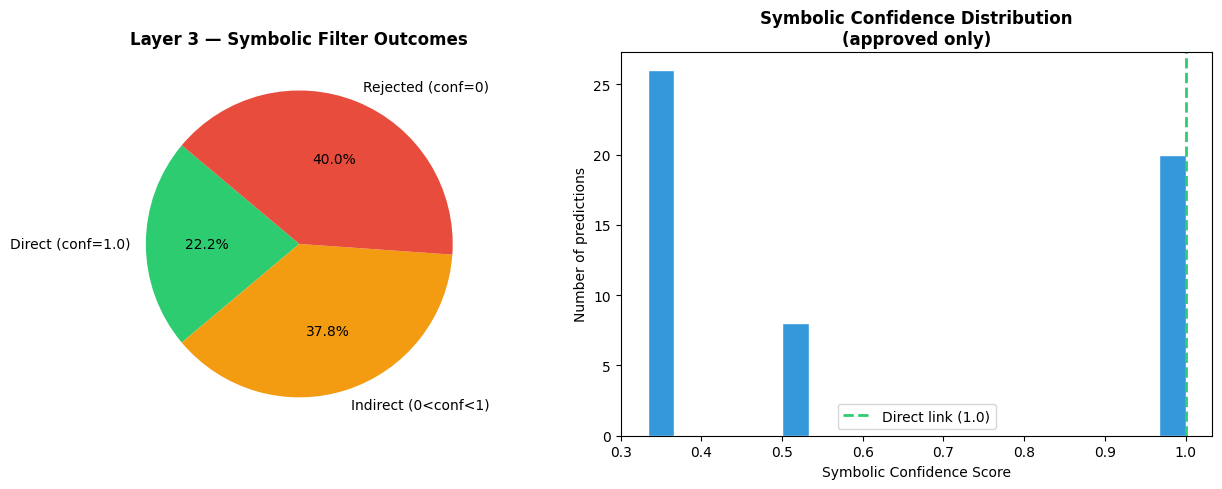

In [9]:
# --- Visualización: resultados del filtro ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart de los tres casos
labels  = ['Direct (conf=1.0)', 'Indirect (0<conf<1)', 'Rejected (conf=0)']
sizes   = [n_direct, n_indirect, n_rejected]
colors  = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie([s for s in sizes if s > 0],
            labels=[l for l, s in zip(labels, sizes) if s > 0],
            colors=[c for c, s in zip(colors, sizes) if s > 0],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Layer 3 — Symbolic Filter Outcomes', fontsize=12, fontweight='bold')

# Distribución de confianza simbólica (solo aprobadas)
approved = df_all[df_all['symbolic_confidence'] > 0]
axes[1].hist(approved['symbolic_confidence'], bins=20, color='#3498db', edgecolor='white')
axes[1].axvline(x=1.0, color='#2ecc71', linestyle='--', linewidth=2, label='Direct link (1.0)')
axes[1].set_xlabel('Symbolic Confidence Score')
axes[1].set_ylabel('Number of predictions')
axes[1].set_title('Symbolic Confidence Distribution\n(approved only)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('layer3_filter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Layer 4 — Neuro-Symbolic Score & Ranking

### Why 30% neural / 70% ontology?

In an ideal scenario where the neural model works well, we would give it
more weight. However, two factors justify giving the **ontology a higher weight (70%)**:

1. **The neural model has low discriminative power**: it assigns the same
   probability to all game elements for the same Java topic (confirmed in
   Section 2.1). This means the neural component adds almost no differentiation
   between game elements — only the score level per topic varies.

2. **The ontology is built by domain experts**: the semantic relations in
   `edgesNew.csv` encode expert knowledge about how Java topics, game elements,
   learning objectives and pedagogical resources relate to each other.
   This is a stronger and more reliable signal than a model trained on 42 examples.

### The formula

$$\text{neurosymbolic\_score} = 0.30 \times p_{\text{neural}} + 0.70 \times c_{\text{symbolic}}$$

Where:
- $p_{\text{neural}}$ = `probability_mean` from Task 2 (average over 5 seeds)
- $c_{\text{symbolic}}$ = ontological confidence from Layer 3 (0 to 1)
- Predictions with $c_{\text{symbolic}} = 0$ are **excluded** (score = 0)

The neural component still matters: it captures the overall "relevance" of
a topic (topics with higher neural scores are generally more gamification-ready),
while the ontology decides which specific game element is the best fit.

In [10]:
# Pesos: más peso a la ontología porque el modelo neuronal no diferencia bien
NEURAL_WEIGHT   = 0.30
SYMBOLIC_WEIGHT = 0.70

def compute_neurosymbolic_score(prob_neural, conf_symbolic):
    """
    Combina el score neuronal y la confianza ontológica.
    Si la confianza simbólica es 0 (rechazado por la ontología), el score es 0.
    """
    if conf_symbolic == 0.0:
        return 0.0
    return NEURAL_WEIGHT * prob_neural + SYMBOLIC_WEIGHT * conf_symbolic

df_all['neurosymbolic_score'] = df_all.apply(
    lambda row: compute_neurosymbolic_score(row['probability_mean'], row['symbolic_confidence']),
    axis=1
)

# Separar aprobadas y rechazadas
df_approved = df_all[df_all['neurosymbolic_score'] > 0].copy()
df_rejected = df_all[df_all['neurosymbolic_score'] == 0].copy()

print(f'Formula : {NEURAL_WEIGHT:.0%} × neural_prob + {SYMBOLIC_WEIGHT:.0%} × symbolic_confidence')
print(f'Approved: {len(df_approved):,}')
print(f'Rejected: {len(df_rejected):,}')
print()
print('Score range (approved):')
print(f'  Max : {df_approved["neurosymbolic_score"].max():.4f}')
print(f'  Min : {df_approved["neurosymbolic_score"].min():.4f}')
print(f'  Mean: {df_approved["neurosymbolic_score"].mean():.4f}')

Formula : 30% × neural_prob + 70% × symbolic_confidence
Approved: 54
Rejected: 36

Score range (approved):
  Max : 0.8849
  Min : 0.2830
  Mean: 0.5790


### 5.1 Global ranking — Top predictions

In [11]:
# Ordenar por score neuro-simbólico descendente
df_ranked = df_approved.sort_values('neurosymbolic_score', ascending=False).reset_index(drop=True)

display_cols = ['source', 'target', 'probability_mean', 'symbolic_confidence',
                'neurosymbolic_score', 'known_positive']

print('=== Global Top-20 Neuro-Symbolic Recommendations ===')
df_ranked[display_cols].head(20)

=== Global Top-20 Neuro-Symbolic Recommendations ===


,source,target,probability_mean,symbolic_confidence,neurosymbolic_score,known_positive
0,Arithmetic_operations,Stash,0.616297,1.0,0.884889,True
1,Task_about_Java_Basics,Level_Up,0.614525,1.0,0.884358,True
2,Task_about_Java_Basics,BLockGame,0.614416,1.0,0.884325,True
3,Task_about_Java_Basics,Stash,0.614416,1.0,0.884325,True
4,Buil-in_Data_Types,Level_Up,0.589158,1.0,0.876747,True
5,Buil-in_Data_Types,Tiny_stash,0.589111,1.0,0.876733,True
6,Overloading,Level_Up,0.560126,1.0,0.868038,True
7,Variables,Level_Up,0.558519,1.0,0.867556,True
8,Variables,Tiny_stash,0.558374,1.0,0.867512,True
9,Functions,Stash,0.555627,1.0,0.866688,True


### 5.2 Per-topic ranking — Top-K

A teacher works with a specific Java topic. We produce the best
game element recommendations for **each topic individually**.

In [12]:
TOP_K = 5

# Para cada topic Java, tomar las TOP_K mejores recomendaciones
df_topk = (
    df_ranked
    .groupby('source', group_keys=False)
    .apply(lambda g: g.nlargest(TOP_K, 'neurosymbolic_score'))
    .reset_index(drop=True)
)

n_topics = df_topk['source'].nunique()
print(f'Top-{TOP_K} recommendations produced for {n_topics} Java topics')
print(f'Total rows in top-K table : {len(df_topk)}')
print()

# Ejemplo para un topic específico
example = df_topk['source'].iloc[0]
print(f'--- Recommendations for: {example} ---')
df_topk[df_topk['source'] == example][display_cols]

Top-5 recommendations produced for 15 Java topics
Total rows in top-K table : 54

--- Recommendations for: Arithmetic_operations ---


,source,target,probability_mean,symbolic_confidence,neurosymbolic_score,known_positive
0,Arithmetic_operations,Stash,0.616297,1.000000,0.884889,True
20,Arithmetic_operations,Level_Up,0.616465,0.500000,0.534940,False
21,Arithmetic_operations,BLockGame,0.616297,0.500000,0.534889,False
28,Arithmetic_operations,Tiny_stash,0.616297,0.333333,0.418223,False


In [13]:
# Mostrar Top-5 para todos los topics de forma legible
print('=== Top-5 per Java topic ===')
for topic, group in df_topk.groupby('source'):
    print(f'\n{topic}:')
    for rank, (_, row) in enumerate(group.iterrows(), 1):
        known = '✓ known' if row['known_positive'] else '  new'
        print(f'  {rank}. {row["target"]:<35} score={row["neurosymbolic_score"]:.4f}  '
              f'[neural={row["probability_mean"]:.3f}, ontology={row["symbolic_confidence"]:.3f}]  {known}')

=== Top-5 per Java topic ===

Arithmetic_operations:
  1. Stash                               score=0.8849  [neural=0.616, ontology=1.000]  ✓ known
  2. Level_Up                            score=0.5349  [neural=0.616, ontology=0.500]    new
  3. BLockGame                           score=0.5349  [neural=0.616, ontology=0.500]    new
  4. Tiny_stash                          score=0.4182  [neural=0.616, ontology=0.333]    new

Buil-in_Data_Types:
  1. Level_Up                            score=0.8767  [neural=0.589, ontology=1.000]  ✓ known
  2. Tiny_stash                          score=0.8767  [neural=0.589, ontology=1.000]  ✓ known
  3. Stash                               score=0.4101  [neural=0.589, ontology=0.333]    new
  4. BLockGame                           score=0.4101  [neural=0.589, ontology=0.333]    new

Control_Statements:
  1. Stash                               score=0.8542  [neural=0.514, ontology=1.000]  ✓ known
  2. BLockGame                           score=0.8542  [neur

## 6. Visualisations

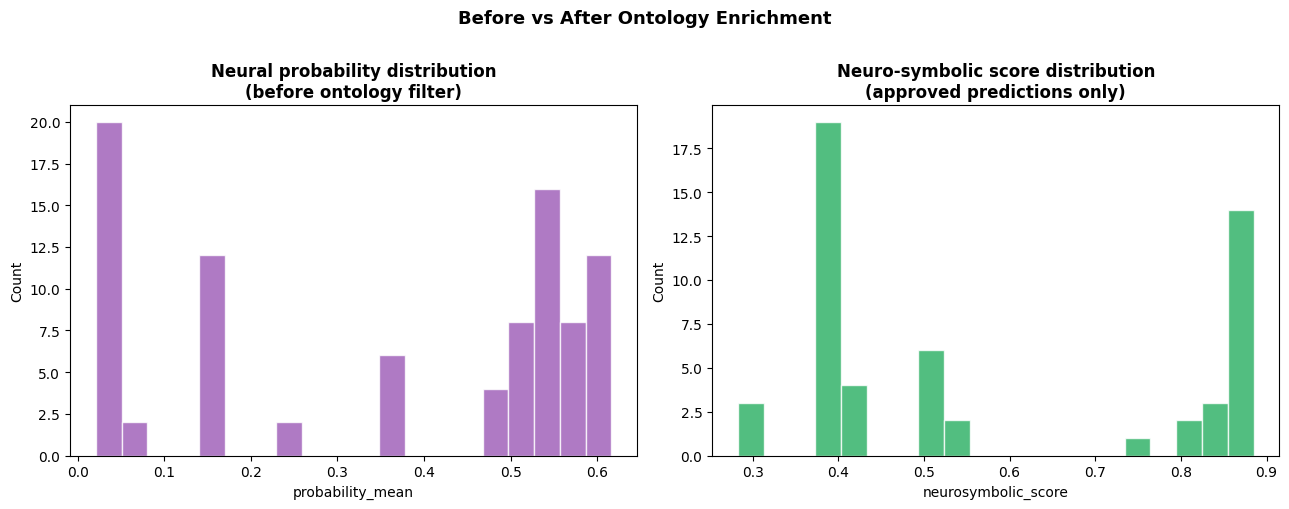

In [14]:
# --- Fig 1: Score distribution — neural vs neuro-symbolic ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_all['probability_mean'], bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].set_title('Neural probability distribution\n(before ontology filter)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('probability_mean')
axes[0].set_ylabel('Count')

axes[1].hist(df_approved['neurosymbolic_score'], bins=20, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_title('Neuro-symbolic score distribution\n(approved predictions only)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('neurosymbolic_score')
axes[1].set_ylabel('Count')

plt.suptitle('Before vs After Ontology Enrichment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('layer4_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

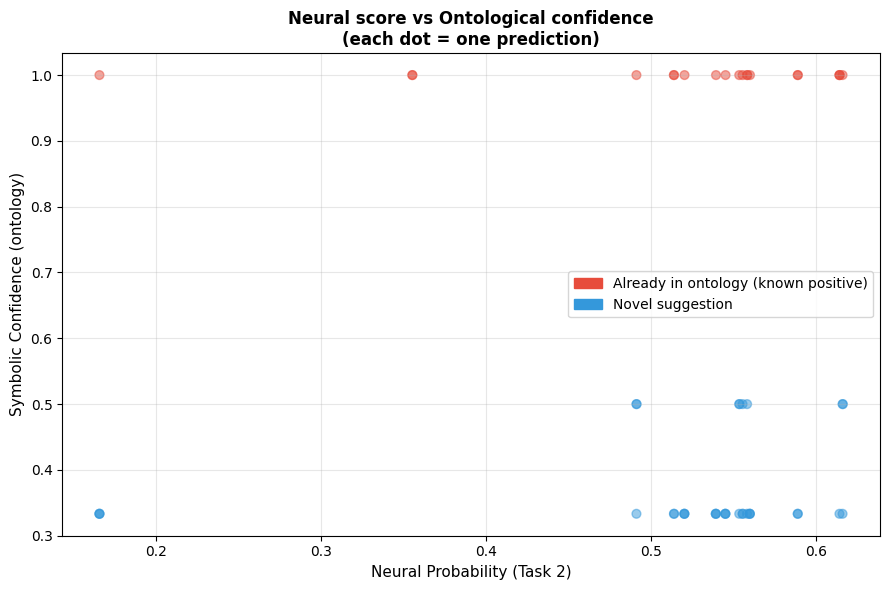

In [15]:
# --- Fig 2: Scatter — neural probability vs symbolic confidence ---
fig, ax = plt.subplots(figsize=(9, 6))

colors_scatter = df_approved['known_positive'].map({True: '#e74c3c', False: '#3498db'})
ax.scatter(df_approved['probability_mean'], df_approved['symbolic_confidence'],
           c=colors_scatter, alpha=0.5, s=40)

ax.set_xlabel('Neural Probability (Task 2)', fontsize=11)
ax.set_ylabel('Symbolic Confidence (ontology)', fontsize=11)
ax.set_title('Neural score vs Ontological confidence\n(each dot = one prediction)', fontsize=12, fontweight='bold')

red_patch  = mpatches.Patch(color='#e74c3c', label='Already in ontology (known positive)')
blue_patch = mpatches.Patch(color='#3498db', label='Novel suggestion')
ax.legend(handles=[red_patch, blue_patch])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('layer4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

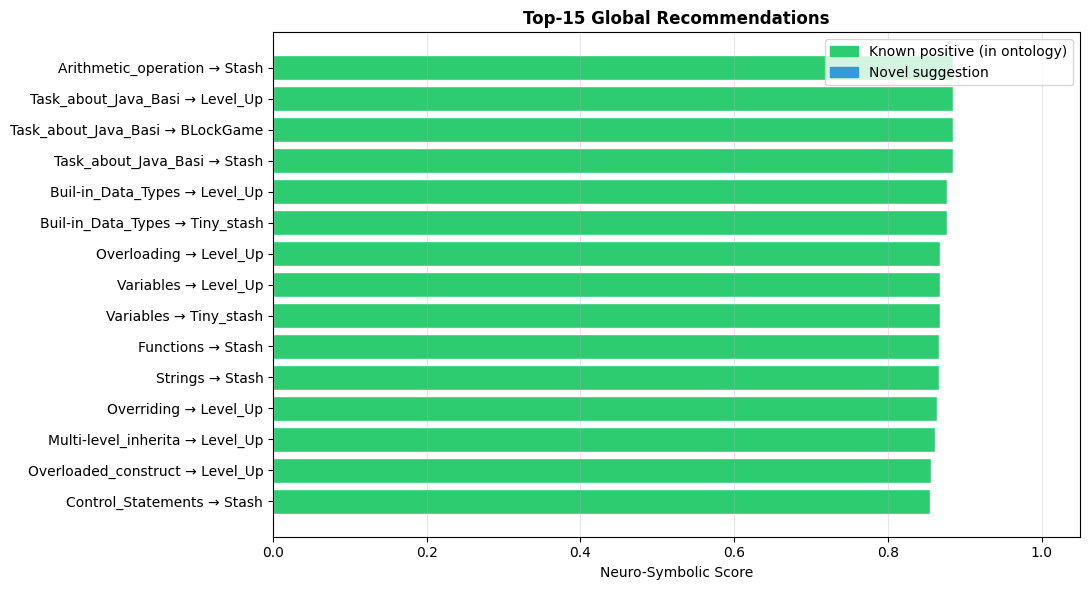

In [16]:
# --- Fig 3: Top-15 global recommendations (bar chart) ---
top15 = df_ranked.head(15).copy()
top15['label'] = top15['source'].str[:20] + ' → ' + top15['target']

fig, ax = plt.subplots(figsize=(11, 6))
colors_bar = ['#2ecc71' if kp else '#3498db' for kp in top15['known_positive'][::-1]]
ax.barh(top15['label'][::-1], top15['neurosymbolic_score'][::-1],
        color=colors_bar, edgecolor='white')

ax.set_xlabel('Neuro-Symbolic Score')
ax.set_title('Top-15 Global Recommendations', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)

green_p = mpatches.Patch(color='#2ecc71', label='Known positive (in ontology)')
blue_p  = mpatches.Patch(color='#3498db', label='Novel suggestion')
ax.legend(handles=[green_p, blue_p])

plt.tight_layout()
plt.savefig('top15_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics

In [17]:
print('=' * 58)
print('  TASK 3 — FINAL SUMMARY')
print('=' * 58)
print(f'  Neural predictions evaluated     : {n_total:>6,}')
print(f'  Rejected by Layer 3 (no path)    : {len(df_rejected):>6,}  ({100*len(df_rejected)/n_total:.1f}%)')
print(f'  Approved                         : {len(df_approved):>6,}  ({100*len(df_approved)/n_total:.1f}%)')
print(f'    of which: direct edge          : {n_direct:>6,}')
print(f'    of which: indirect path        : {n_indirect:>6,}')
print()
print(f'  Java topics covered              : {df_topk["source"].nunique():>6}')
print(f'  Top-{TOP_K} recommendations produced  : {len(df_topk):>6,}')
print()
print(f'  Weighting formula : {NEURAL_WEIGHT:.0%} neural + {SYMBOLIC_WEIGHT:.0%} ontology')
print(f'  Max score         : {df_approved["neurosymbolic_score"].max():.4f}')
print(f'  Min score (appr.) : {df_approved["neurosymbolic_score"].min():.4f}')
print(f'  Mean score (appr.): {df_approved["neurosymbolic_score"].mean():.4f}')
print('=' * 58)

  TASK 3 — FINAL SUMMARY
  Neural predictions evaluated     :     90
  Rejected by Layer 3 (no path)    :     36  (40.0%)
  Approved                         :     54  (60.0%)
    of which: direct edge          :     20
    of which: indirect path        :     34

  Java topics covered              :     15
  Top-5 recommendations produced  :     54

  Weighting formula : 30% neural + 70% ontology
  Max score         : 0.8849
  Min score (appr.) : 0.2830
  Mean score (appr.): 0.5790


## 8. Save Outputs

In [19]:
import os
os.makedirs('task3', exist_ok=True)

# Todas las predicciones aprobadas, ordenadas por score
df_ranked.to_csv('task3/task3_all_approved_ranked.csv', index=False)

# Top-K por topic Java — este es el output principal para Task 4
df_topk.to_csv('task3/task3_topk_per_topic.csv', index=False)

# Predicciones rechazadas — útil para el informe
df_rejected.to_csv('task3/task3_rejected_predictions.csv', index=False)

print('Output files saved:')
print(f'  task3_all_approved_ranked.csv  — {len(df_ranked):,} rows')
print(f'  task3_topk_per_topic.csv       — {len(df_topk):,} rows  ← main output for Task 4')
print(f'  task3_rejected_predictions.csv — {len(df_rejected):,} rows')

Output files saved:
  task3_all_approved_ranked.csv  — 54 rows
  task3_topk_per_topic.csv       — 54 rows  ← main output for Task 4
  task3_rejected_predictions.csv — 36 rows


## 9. Text for the Report

> **Task 3 — Neuro-Symbolic Filtering and Ranking**
>
> Layer 3 implements a symbolic gatekeeper that evaluates every candidate
> recommendation produced by the neural model (Task 2) against the ontology
> knowledge graph built in Task 1. For each `(Java topic, game element)` pair,
> a symbolic confidence score is computed based on the shortest path length
> between the two nodes in the undirected ontology graph: a direct edge yields
> a confidence of 1.0, an indirect path of length d yields 1/d, and the
> complete absence of any path yields 0.0, causing the prediction to be
> rejected entirely.
>
> In Layer 4, approved predictions are combined into a final neuro-symbolic
> score using a weighted formula: 0.30 × p_neural + 0.70 × c_symbolic.
> The higher ontological weight (70%) is justified by two factors: first, the
> neural model assigns identical probabilities to all game elements for the
> same Java topic (due to the very small training set of 60 examples),
> providing no differential signal between elements; second, the ontology
> encodes expert-validated knowledge about the pedagogical relations between
> Java concepts and game elements, making it the more reliable source for
> fine-grained ranking. The predictions are then sorted by their neuro-symbolic
> score and the top-K recommendations are produced per Java topic.